<a href="https://colab.research.google.com/github/SKSAHILAKHTAR1/AI-Powered-SDR-Laboratory/blob/main/DPCM%20and%20delta%20modulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Critical Step Size (Delta_crit) = 0.1257 V
Case 1 (Slope Overload, Delta=0.0440 V)  : MSE = 0.30564
Case 2 (Optimal Tracking, Delta=0.1445 V)  : MSE = 0.00697
Case 3 (Granular Noise,  Delta=0.4398 V) : MSE = 0.06626
Case 4 (3-bit DPCM Simulation)                       : MSE = 0.00186


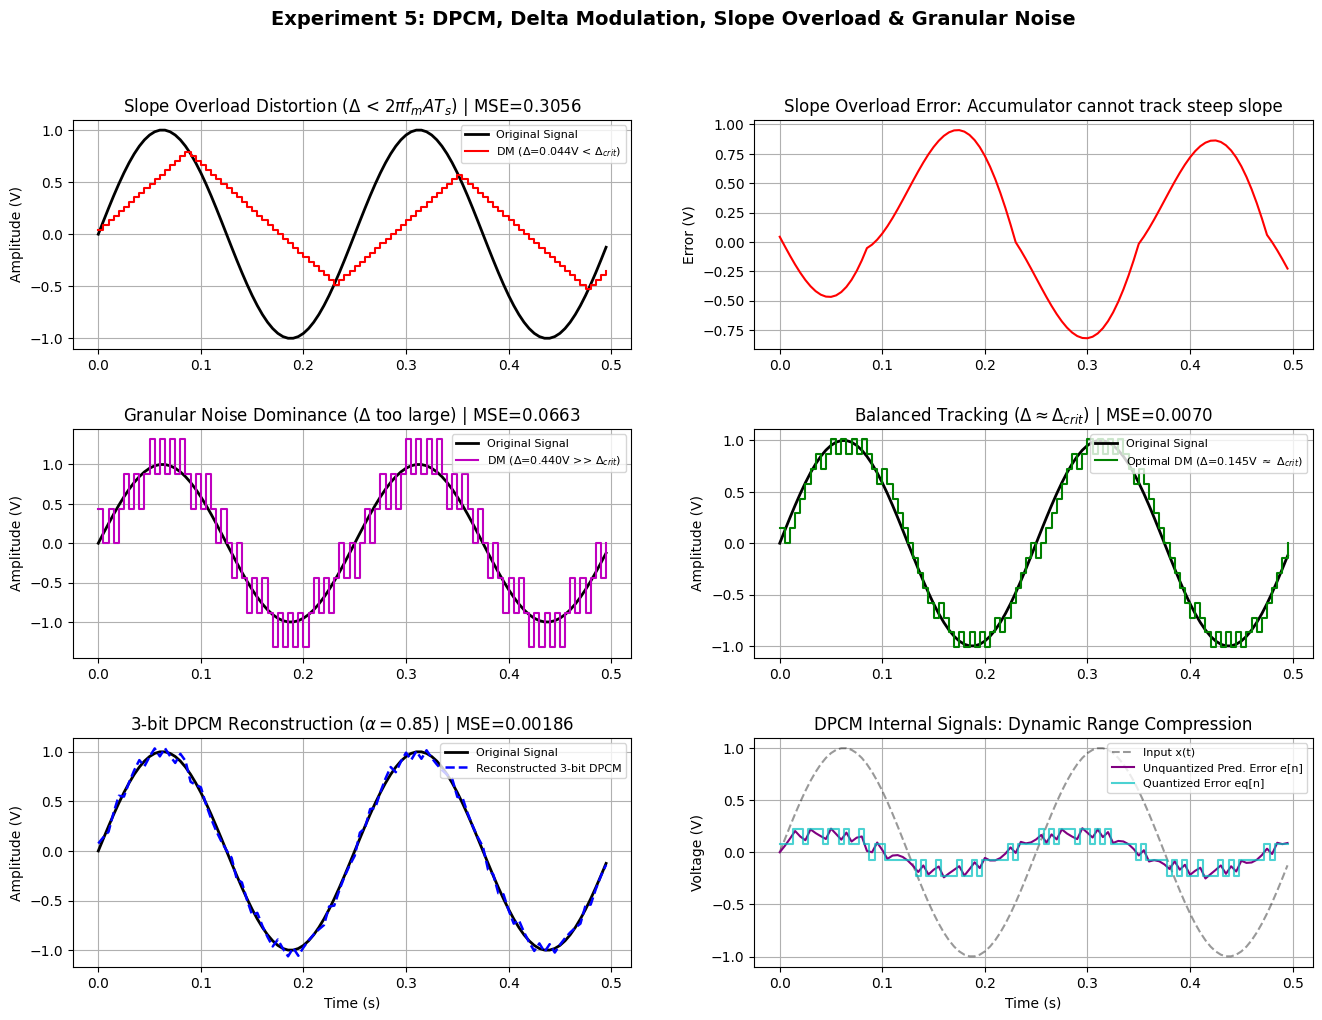

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ====================================================================
# 1. TEST SIGNAL GENERATION
# ====================================================================
A = 1.0               # Peak amplitude (V)
fm = 4.0              # Message frequency (Hz)
fs = 200.0            # Sampling frequency (samples/sec)
Ts = 1.0 / fs
duration = 0.5        # Duration in seconds
t = np.arange(0, duration, Ts)

# Continuous-like message signal
x = A * np.sin(2 * np.pi * fm * t)

# Critical step size to prevent slope overload: Delta_crit = 2 * pi * fm * A * Ts
Delta_crit = 2 * np.pi * fm * A * Ts  # approx 0.1257 V

# ====================================================================
# 2. DELTA MODULATION SIMULATION ENGINE
# ====================================================================
def simulate_delta_modulation(sig, delta):
    """
    Simulates a Delta Modulator and demodulator.
    Returns: reconstructed signal, quantization error, and binary bitstream.
    """
    N = len(sig)
    x_hat = np.zeros(N)
    bits = np.zeros(N, dtype=int)
    error = np.zeros(N)

    current_estimate = 0.0
    for i in range(N):
        diff = sig[i] - current_estimate
        if diff >= 0:
            bits[i] = 1
            step = delta
        else:
            bits[i] = 0
            step = -delta

        current_estimate += step
        x_hat[i] = current_estimate
        error[i] = x_hat[i] - sig[i]

    return x_hat, error, bits

# Three Cases:
# Case 1: Slope Overload (Delta too small)
Delta_small = 0.35 * Delta_crit
# Case 2: Optimal Tracking (Delta approximately critical)
Delta_opt = 1.15 * Delta_crit
# Case 3: Dominant Granular Noise (Delta too large)
Delta_large = 3.50 * Delta_crit

x_hat_small, err_small, bits_small = simulate_delta_modulation(x, Delta_small)
x_hat_opt, err_opt, bits_opt = simulate_delta_modulation(x, Delta_opt)
x_hat_large, err_large, bits_large = simulate_delta_modulation(x, Delta_large)

# ====================================================================
# 3. FIRST-ORDER DPCM ENGINE
# ====================================================================
def simulate_dpcm(sig, n_bits=3, alpha=0.85):
    """
    First-order linear predictive DPCM with uniform mid-rise error quantizer.
    """
    N = len(sig)
    x_hat = np.zeros(N)
    pred_error = np.zeros(N)
    q_pred_error = np.zeros(N)

    # Range of prediction error
    e_max = 0.6
    e_min = -0.6
    L = 2 ** n_bits
    Delta_dpcm = (e_max - e_min) / L
    q_levels = e_min + (np.arange(L) + 0.5) * Delta_dpcm

    x_tilde = 0.0  # Reconstructed sample at previous step
    for i in range(N):
        x_pred = alpha * x_tilde
        e = sig[i] - x_pred
        pred_error[i] = e

        # Quantize prediction error
        idx = int(np.clip(np.floor((e - e_min) / Delta_dpcm), 0, L - 1))
        eq = q_levels[idx]
        q_pred_error[i] = eq

        x_tilde = x_pred + eq
        x_hat[i] = x_tilde

    rec_error = x_hat - sig
    return x_hat, pred_error, q_pred_error, rec_error

x_dpcm, e_dpcm, eq_dpcm, err_dpcm = simulate_dpcm(x, n_bits=3, alpha=0.85)

# Calculate MSE for all models
mse_small = np.mean(err_small ** 2)
mse_opt = np.mean(err_opt ** 2)
mse_large = np.mean(err_large ** 2)
mse_dpcm = np.mean(err_dpcm ** 2)

print(f"Critical Step Size (Delta_crit) = {Delta_crit:.4f} V")
print(f"Case 1 (Slope Overload, Delta={Delta_small:.4f} V)  : MSE = {mse_small:.5f}")
print(f"Case 2 (Optimal Tracking, Delta={Delta_opt:.4f} V)  : MSE = {mse_opt:.5f}")
print(f"Case 3 (Granular Noise,  Delta={Delta_large:.4f} V) : MSE = {mse_large:.5f}")
print(f"Case 4 (3-bit DPCM Simulation)                       : MSE = {mse_dpcm:.5f}")

# ====================================================================
# 4. COMPREHENSIVE VISUALIZATION
# ====================================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 11))
plt.subplots_adjust(hspace=0.35, wspace=0.22)
fig.suptitle("Experiment 5: DPCM, Delta Modulation, Slope Overload & Granular Noise", fontsize=14, fontweight='bold')

# Plot 1: Slope Overload Distortion (Case 1)
axes[0, 0].plot(t, x, 'k-', label='Original Signal', lw=2)
axes[0, 0].step(t, x_hat_small, 'r-', where='post', label=rf'DM ($\Delta$={Delta_small:.3f}V < $\Delta_{{crit}}$)')
axes[0, 0].set_title(rf"Slope Overload Distortion ($\Delta$ < 2$\pi f_m A T_s$) | MSE={mse_small:.4f}")
axes[0, 0].set_ylabel("Amplitude (V)")
axes[0, 0].grid(True)
axes[0, 0].legend(loc='upper right', fontsize=8)

# Plot 2: Error in Slope Overload
axes[0, 1].plot(t, err_small, 'r-', lw=1.5)
axes[0, 1].set_title("Slope Overload Error: Accumulator cannot track steep slope")
axes[0, 1].set_ylabel("Error (V)")
axes[0, 1].grid(True)

# Plot 3: Granular (Idle Channel) Noise (Case 3)
axes[1, 0].plot(t, x, 'k-', label='Original Signal', lw=2)
axes[1, 0].step(t, x_hat_large, 'm-', where='post', label=rf'DM ($\Delta$={Delta_large:.3f}V >> $\Delta_{{crit}}$)')
axes[1, 0].set_title(rf"Granular Noise Dominance ($\Delta$ too large) | MSE={mse_large:.4f}")
axes[1, 0].set_ylabel("Amplitude (V)")
axes[1, 0].grid(True)
axes[1, 0].legend(loc='upper right', fontsize=8)

# Plot 4: Optimal DM Tracking (Case 2)
axes[1, 1].plot(t, x, 'k-', label='Original Signal', lw=2)
axes[1, 1].step(t, x_hat_opt, 'g-', where='post', label=rf'Optimal DM ($\Delta$={Delta_opt:.3f}V $\approx$ $\Delta_{{crit}}$)')
axes[1, 1].set_title(rf"Balanced Tracking ($\Delta \approx \Delta_{{crit}}$) | MSE={mse_opt:.4f}")
axes[1, 1].set_ylabel("Amplitude (V)")
axes[1, 1].grid(True)
axes[1, 1].legend(loc='upper right', fontsize=8)

# Plot 5: DPCM Waveform vs Original
axes[2, 0].plot(t, x, 'k-', label='Original Signal', lw=2)
axes[2, 0].plot(t, x_dpcm, 'b--', label='Reconstructed 3-bit DPCM', lw=1.8)
axes[2, 0].set_title(rf"3-bit DPCM Reconstruction ($\alpha=0.85$) | MSE={mse_dpcm:.5f}")
axes[2, 0].set_xlabel("Time (s)")
axes[2, 0].set_ylabel("Amplitude (V)")
axes[2, 0].grid(True)
axes[2, 0].legend(loc='upper right', fontsize=8)

# Plot 6: DPCM Prediction Error Reduction
axes[2, 1].plot(t, x, 'k--', alpha=0.4, label='Input x(t)')
axes[2, 1].plot(t, e_dpcm, 'purple', label='Unquantized Pred. Error e[n]')
axes[2, 1].step(t, eq_dpcm, 'c', where='mid', alpha=0.7, label='Quantized Error eq[n]')
axes[2, 1].set_title("DPCM Internal Signals: Dynamic Range Compression")
axes[2, 1].set_xlabel("Time (s)")
axes[2, 1].set_ylabel("Voltage (V)")
axes[2, 1].grid(True)
axes[2, 1].legend(loc='upper right', fontsize=8)

plt.show()